# Randomisation Inference Simulation

Compares two inferential approaches for each assignment design:

| Approach | SE source | Valid for BWD? |
|---|---|---|
| **Neyman** | Sample variances (ignores design) | Conservative — overcoverage, lower power |
| **Randomisation Inference** | Re-run BWD B times | Exploits known assignment mechanism |

Metrics measured per design per iteration:
- `NeymanCoverage` / `RI_Coverage` — does the 95% CI contain the true ATE?
- `NeymanRejects` / `RI_Rejects` — do we reject H0: tau=0 when a real effect exists?
- `ATEError` — bias of the point estimate
- `CovariateMSE` — covariate imbalance between groups

In [ ]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

In [ ]:
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import balancer as bal
import estimator as est
import evaluator as evl
from alias import *
from alias import dgp

importlib.reload(evl)

In [5]:
# simulation parameters
B = 100  # RI re-runs (increase to 500 for final results)
NUM_ITERS = 100  # iterations per cell (increase to 500 for final)
ALPHA = 0.20  # as Drew suggested — targeting 80% nominal level
sample_sizes = [100, 250, 500, 1000]

In [6]:
def make_plan(phi):
    plan = Plan()

    plan.add_design("Simple", bal.Simple, est.DifferenceInMeans, {})
    plan.add_design(f"BWD(phi={phi})", bal.BWD, est.DifferenceInMeans, {"phi": phi})

    plan.add_evaluator("ATEError", evl.ATEError)
    plan.add_evaluator("CovariateMSE", evl.CovariateMSE)
    plan.add_evaluator("CISize", evl.CISize)
    plan.add_evaluator("NeymanCoverage", evl.ATECovers)
    plan.add_evaluator("NeymanRejects", evl.NeymanRejects, {"alpha": ALPHA})

    bwd_kwargs = {"phi": phi, "delta": 0.05}

    # RI_PValue — no alpha argument
    plan.add_evaluator(
        "RI_PValue",
        evl.RandomisationInferencePValue,
        {
            "balancer_class": bal.BWD,
            "balancer_kwargs": bwd_kwargs,
            "B": B,
        },
    )

    # RI_Coverage and RI_Rejects — have alpha argument
    plan.add_evaluator(
        "RI_Coverage",
        evl.RandomisationInferenceCoverage,
        {
            "balancer_class": bal.BWD,
            "balancer_kwargs": bwd_kwargs,
            "B": B,
            "alpha": ALPHA,
        },
    )
    plan.add_evaluator(
        "RI_Rejects",
        evl.RandomisationInferenceRejects,
        {
            "balancer_class": bal.BWD,
            "balancer_kwargs": bwd_kwargs,
            "B": B,
            "alpha": ALPHA,
        },
    )

    return plan


plan_phi1 = make_plan(phi=1.0)
plan_phi05 = make_plan(phi=0.5)

In [7]:
os.makedirs("../results/inference", exist_ok=True)

dgp_factory_classes = [
    (dgp.LinearFactory, {"pate": 0.1}),
    (dgp.LinearDriftFactory, {"pate": 0.1}),
    (dgp.LinearSeasonFactory, {"pate": 0.1}),
    (dgp.QuadraticFactory, {"pate": 0.1}),
    (dgp.CubicFactory, {"pate": 0.1}),
    (dgp.SinusoidalFactory, {"pate": 0.1}),
    (dgp.QuickBlockFactory, {"pate": 0.1}),
]

dfs = []

for sample_size in sample_sizes:
    print(f"\nSample size: {sample_size}", flush=True)
    for factory_class, factory_kwargs in dgp_factory_classes:
        factory = factory_class(N=sample_size, **factory_kwargs)
        dgp_name = type(factory.create_dgp()).__name__
        print(f"  DGP: {dgp_name}", flush=True)

        for phi, plan in [(1.0, plan_phi1), (0.5, plan_phi05)]:
            for it in tqdm(range(NUM_ITERS), desc=f"phi={phi}"):
                result = plan.execute(factory, seed=it * 1001)
                result["iteration"] = it
                result["sample_size"] = sample_size
                result["dgp"] = dgp_name
                dfs.append(result)

results = pd.concat(dfs, ignore_index=True)
results.to_csv("../results/inference/all_dgp_results.csv.gz", index=False)
print("\nDone.")


Sample size: 100
  DGP: LinearDGP


phi=1.0:   0%|          | 0/100 [00:00<?, ?it/s]

phi=0.5: 100%|██████████| 100/100 [00:16<00:00,  6.10it/s]

  DGP: LinearDriftDGP



phi=0.5: 100%|██████████| 100/100 [00:15<00:00,  6.52it/s]

...

  DGP: SinusoidalDGP



phi=0.5: 100%|██████████| 100/100 [02:02<00:00,  1.23s/it]

  DGP: QuickBlockDGP



phi=0.5: 100%|██████████| 100/100 [02:02<00:00,  1.22s/it]



Done.


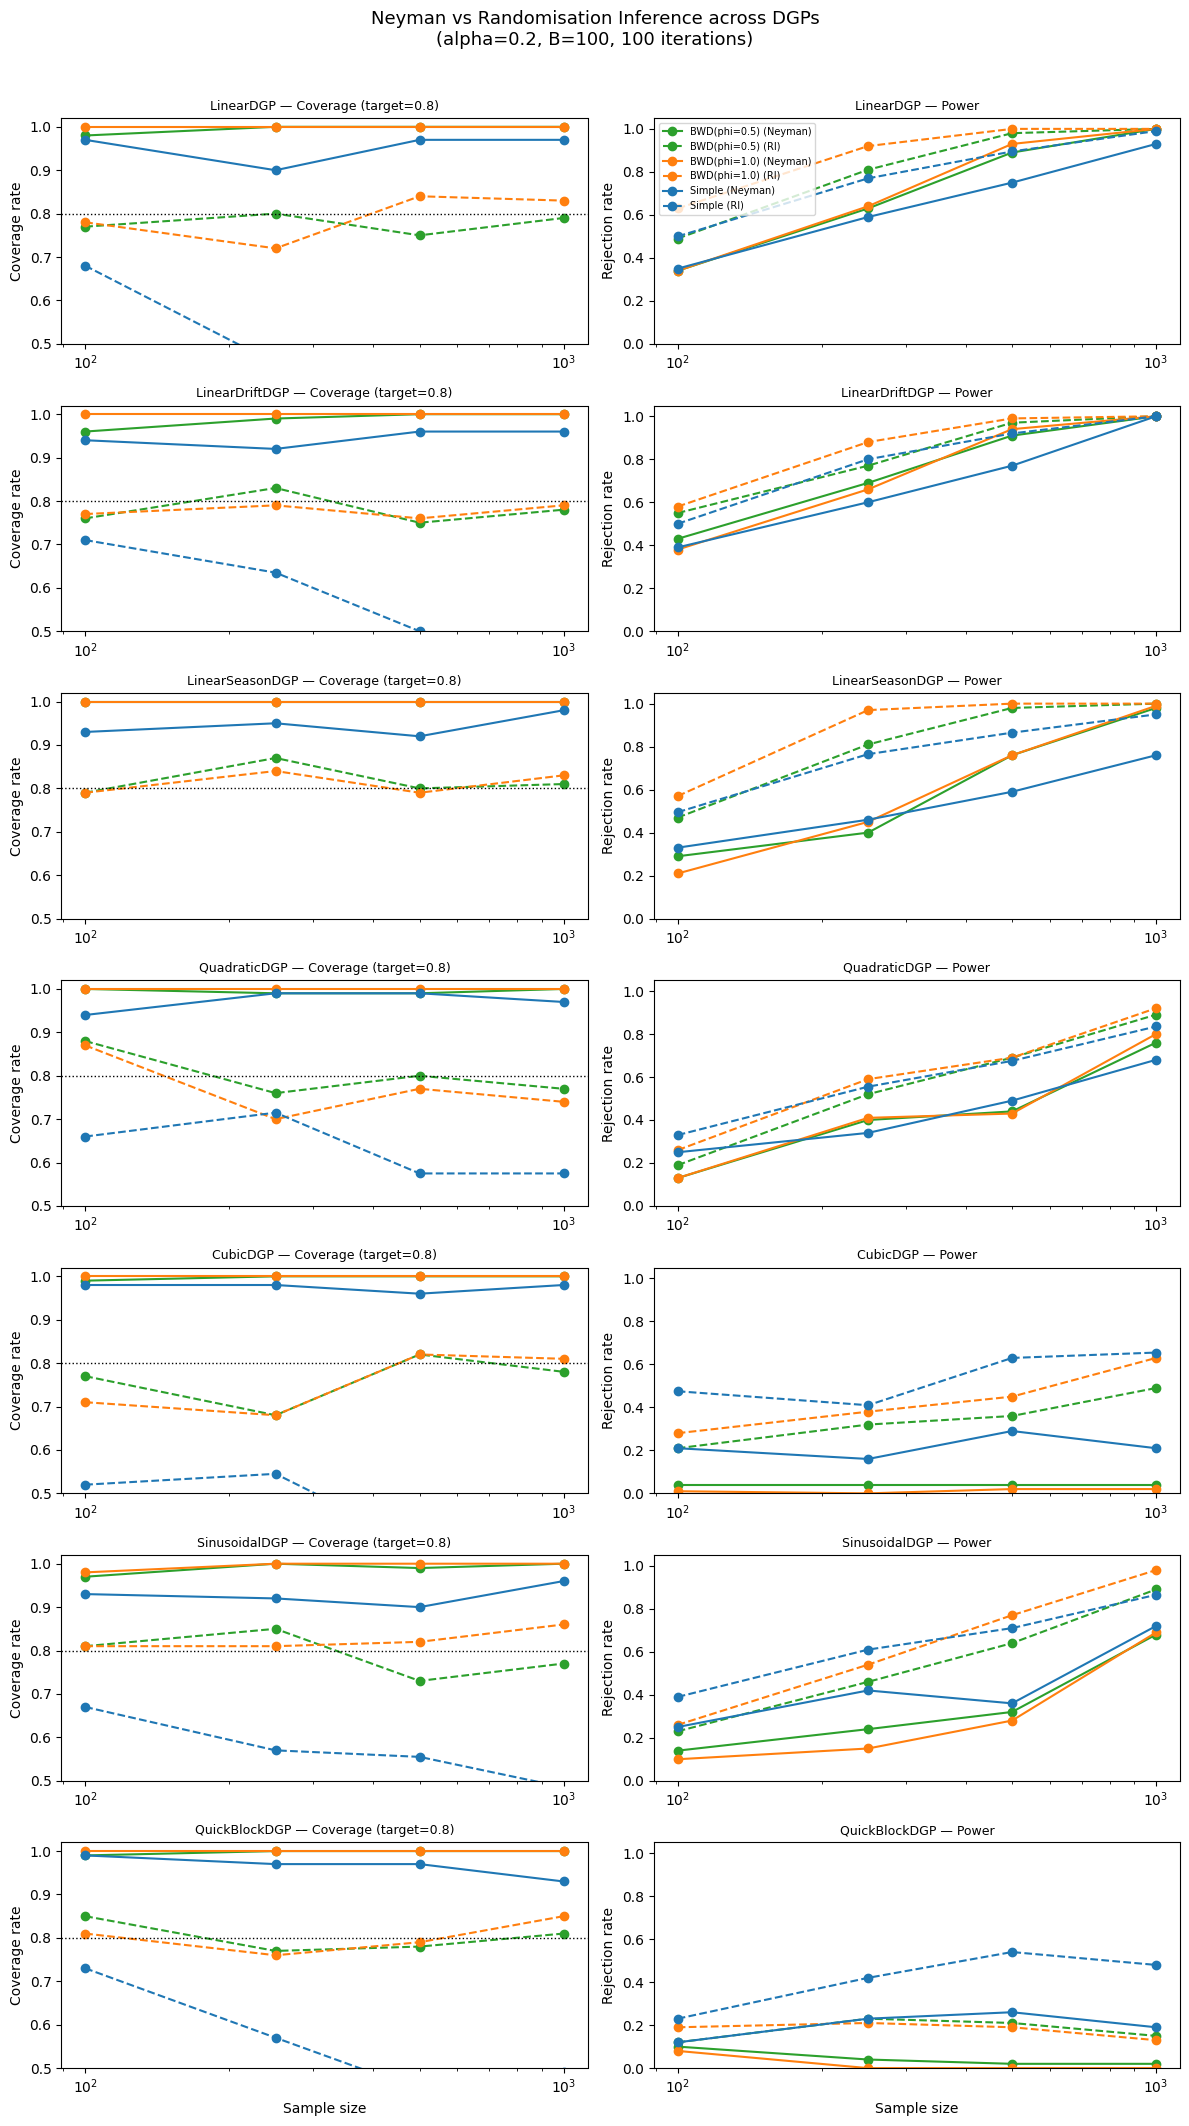

In [10]:
dgp_names = results["dgp"].unique()
n_dgps = len(dgp_names)
key_metrics = ["NeymanRejects", "RI_Rejects", "NeymanCoverage", "RI_Coverage"]

summary = (
    results.groupby(["dgp", "sample_size", "design", "metric"])["value"]
    .mean()
    .reset_index()
)

# One row per DGP, two columns (coverage, power)
fig, axes = plt.subplots(n_dgps, 2, figsize=(12, 3 * n_dgps), sharex=False)
fig.suptitle(
    f"Neyman vs Randomisation Inference across DGPs\n"
    f"(alpha={ALPHA}, B={B}, {NUM_ITERS} iterations)",
    fontsize=13,
    y=1.01,
)

colors = {"Simple": "#1f77b4", "BWD(phi=1.0)": "#ff7f0e", "BWD(phi=0.5)": "#2ca02c"}
nominal = 1 - ALPHA  # 0.80

for row, dgp_name in enumerate(dgp_names):
    sub = summary[summary["dgp"] == dgp_name]
    ax_cov, ax_pow = axes[row, 0], axes[row, 1]

    for design in sub["design"].unique():
        color = colors.get(design, "grey")
        d = sub[sub["design"] == design]

        # Coverage
        for metric, ls in [("NeymanCoverage", "-"), ("RI_Coverage", "--")]:
            m = d[d["metric"] == metric]
            if not m.empty:
                label = f"{design} ({'Neyman' if ls == '-' else 'RI'})"
                ax_cov.plot(
                    m["sample_size"],
                    m["value"],
                    color=color,
                    linestyle=ls,
                    marker="o",
                    label=label,
                    linewidth=1.5,
                )

        # Power
        for metric, ls in [("NeymanRejects", "-"), ("RI_Rejects", "--")]:
            m = d[d["metric"] == metric]
            if not m.empty:
                label = f"{design} ({'Neyman' if ls == '-' else 'RI'})"
                ax_pow.plot(
                    m["sample_size"],
                    m["value"],
                    color=color,
                    linestyle=ls,
                    marker="o",
                    label=label,
                    linewidth=1.5,
                )

    # Formatting
    ax_cov.axhline(nominal, color="black", linestyle=":", linewidth=1)
    ax_cov.set_title(f"{dgp_name} — Coverage (target={nominal})", fontsize=9)
    ax_cov.set_ylabel("Coverage rate")
    ax_cov.set_xscale("log")
    ax_cov.set_ylim(0.5, 1.02)

    ax_pow.set_title(f"{dgp_name} — Power", fontsize=9)
    ax_pow.set_ylabel("Rejection rate")
    ax_pow.set_xscale("log")
    ax_pow.set_ylim(0, 1.05)

    if row == n_dgps - 1:
        ax_cov.set_xlabel("Sample size")
        ax_pow.set_xlabel("Sample size")

    if row == 0:
        ax_pow.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(
    "../results/figures/all_dgp_coverage_power.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [17]:
results = pd.concat(dfs, ignore_index=True)

summary = (
    results.groupby(["dgp", "sample_size", "design", "metric"])["value"]
    .mean()
    .reset_index()
)

key_metrics = [
    "NeymanCoverage",
    "RI_Coverage",
    "NeymanRejects",
    "RI_Rejects",
    "CovariateMSE",
]

table = (
    summary[summary["metric"].isin(key_metrics)]
    .pivot_table(
        index=["dgp", "sample_size", "design"], columns="metric", values="value"
    )
    .round(3)
)

table.to_csv("../results/tables/inference_summary_all_dgps.csv")